In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [68]:
import os
import warnings
import subprocess
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"       : 110,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

print("✅ Libraries ready")
print(f"   numpy  {np.__version__}  |  pandas {pd.__version__}")

✅ Libraries ready
   numpy  2.4.6  |  pandas 2.3.3


In [69]:

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [70]:
import kagglehub

path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")
print("Dataset path:", path)
print("   Files:", os.listdir(path))

Dataset path: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025
   Files: ['tesla_deliveries_dataset_2015_2025.csv']


In [71]:
csv_file = os.path.join(path, "tesla_deliveries_dataset_2015_2025.csv")
df = pd.read_csv(csv_file)

print(f"Loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

✅ Loaded  →  2,640 rows × 12 columns


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [72]:
print(f"Shape   : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print()
df.info()

Shape   : 2,640 rows  ×  12 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [73]:

missing    = df.isnull().sum()
duplicates = df.duplicated().sum()



In [74]:
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std","max"])

,count,mean,std,min,25%,50%,75%,max
Year,2640.000000,2020.000000,3.162877,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Month,2640.000000,6.500000,3.452707,1.000000,3.750000,6.500000,9.250000,12.000000
Estimated_Deliveries,2640.000000,9922.199621,3935.950093,48.000000,7292.000000,9857.000000,12510.250000,25704.000000
Production_Units,2640.000000,10655.847348,4260.600858,50.000000,7828.250000,10546.500000,13469.000000,28939.000000
Avg_Price_USD,2640.000000,84907.340330,20123.258036,50003.700000,67726.365000,85058.510000,102373.042500,119965.360000
Battery_Capacity_kWh,2640.000000,87.059470,20.836265,60.000000,75.000000,82.000000,100.000000,120.000000
Range_km,2640.000000,500.257576,120.868549,330.000000,418.000000,470.000000,586.250000,719.000000
CO2_Saved_tons,2640.000000,744.076989,353.221224,3.070000,499.620000,699.515000,943.765000,2548.550000
Charging_Stations,2640.000000,8932.133712,3469.565883,3002.000000,5897.750000,8901.500000,11938.000000,14996.000000


In [75]:
for col in ["Region", "Model", "Source_Type"]:
    print(f"\n{'─'*45}")
    print(f"  {col}  ({df[col].nunique()} unique values)")
    print(f"{'─'*45}")
    print(df[col].value_counts().to_string())


─────────────────────────────────────────────
  Region  (4 unique values)
─────────────────────────────────────────────
Region
Europe           660
Asia             660
North America    660
Middle East      660

─────────────────────────────────────────────
  Model  (5 unique values)
─────────────────────────────────────────────
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528

─────────────────────────────────────────────
  Source_Type  (3 unique values)
─────────────────────────────────────────────
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872


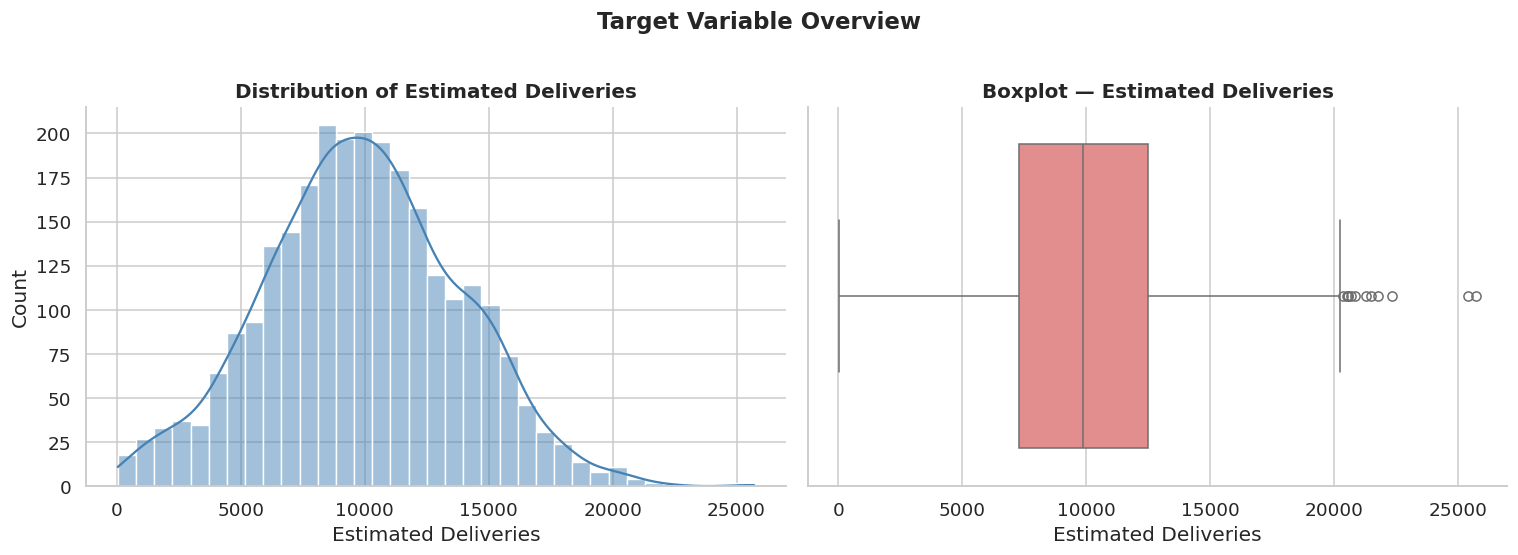

In [76]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Estimated_Deliveries"], kde=True, bins=35,
             color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Estimated Deliveries", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Estimated Deliveries")
axes[0].set_ylabel("Count")

sns.boxplot(x=df["Estimated_Deliveries"], color="lightcoral", ax=axes[1])
axes[1].set_title("Boxplot — Estimated Deliveries", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Estimated Deliveries")

plt.suptitle("Target Variable Overview", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

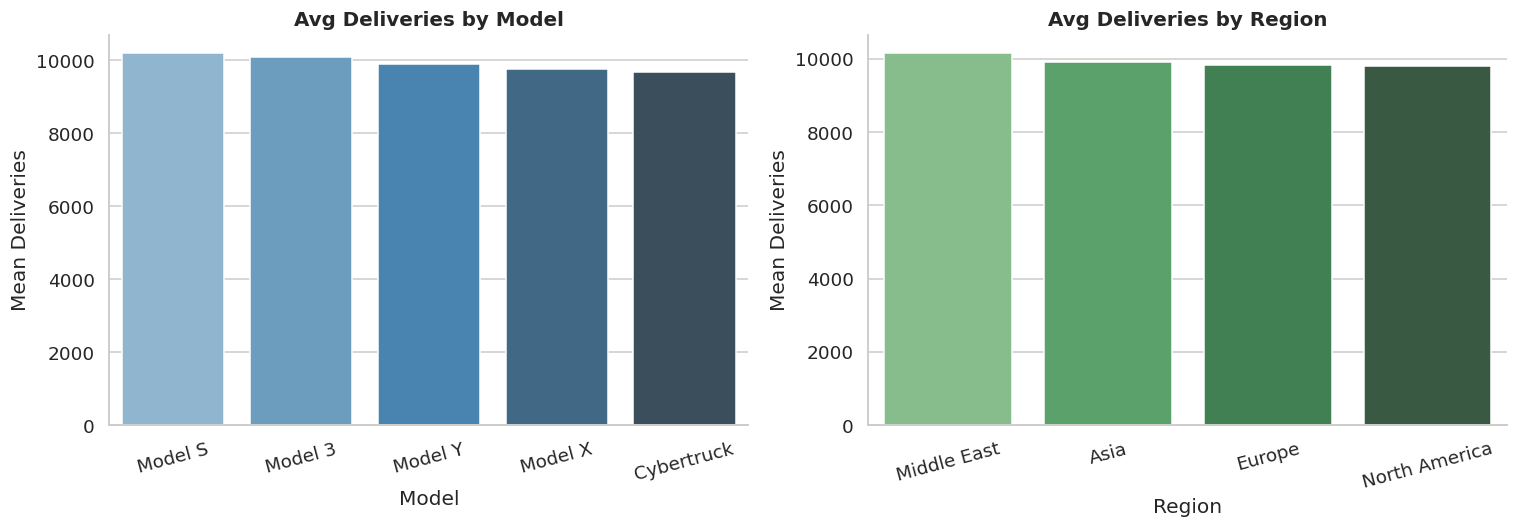

In [77]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_order  = (df.groupby("Model")["Estimated_Deliveries"]
                  .mean().sort_values(ascending=False).index)
region_order = (df.groupby("Region")["Estimated_Deliveries"]
                  .mean().sort_values(ascending=False).index)

sns.barplot(data=df, x="Model", y="Estimated_Deliveries",
            order=model_order, estimator=np.mean, errorbar=None,
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Avg Deliveries by Model", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Mean Deliveries")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=df, x="Region", y="Estimated_Deliveries",
            order=region_order, estimator=np.mean, errorbar=None,
            palette="Greens_d", ax=axes[1])
axes[1].set_title("Avg Deliveries by Region", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Mean Deliveries")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

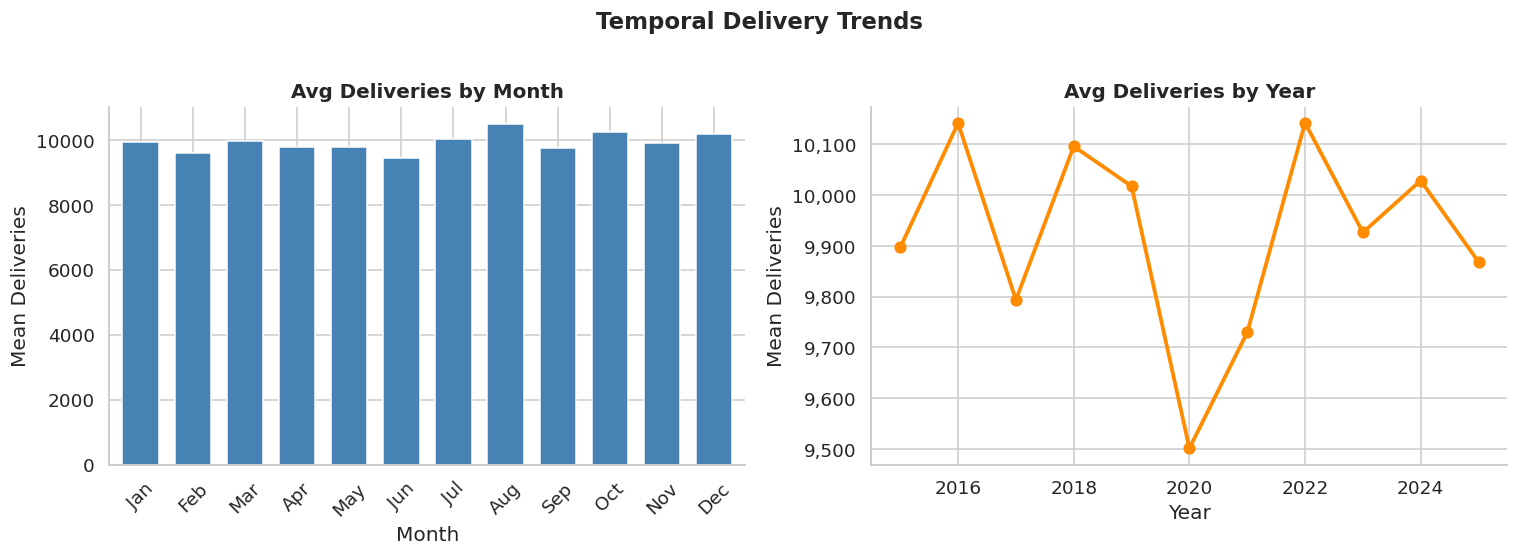

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby("Month")["Estimated_Deliveries"].mean()
monthly.plot(kind="bar", color="steelblue", edgecolor="white",
             ax=axes[0], width=0.7)
axes[0].set_title("Avg Deliveries by Month", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Mean Deliveries")
axes[0].set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
    rotation=45)

yearly = df.groupby("Year")["Estimated_Deliveries"].mean()
yearly.plot(marker="o", markersize=7, linewidth=2.5,
            color="darkorange", ax=axes[1])
axes[1].set_title("Avg Deliveries by Year", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mean Deliveries")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

plt.suptitle("Temporal Delivery Trends", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

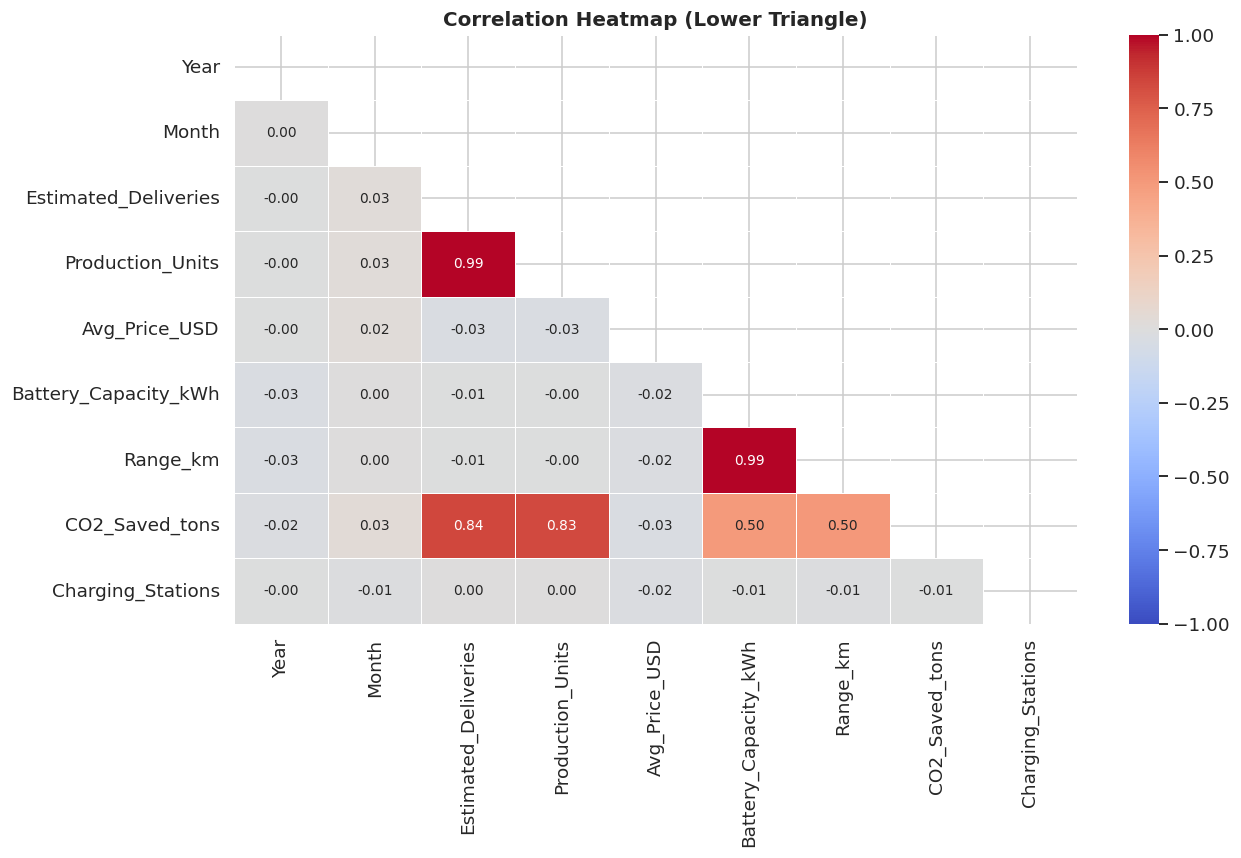

In [79]:

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 9}, vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

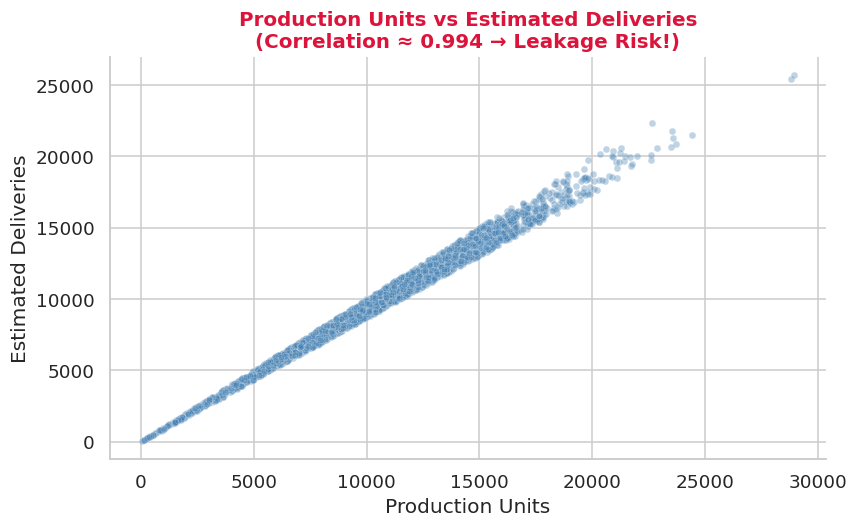

In [80]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries",
                alpha=0.35, color="steelblue", s=20)
plt.title("Production Units vs Estimated Deliveries\n(Correlation ≈ 0.994 → Leakage Risk!)",
          fontsize=13, fontweight="bold", color="crimson")
plt.xlabel("Production Units"); plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

In [81]:

target_corr = (df.select_dtypes(include=[np.number])
                 .corr()["Estimated_Deliveries"]
                 .drop("Estimated_Deliveries")
                 .abs()
                 .sort_values(ascending=False))

print("Feature correlations with Estimated_Deliveries (absolute):")
print(target_corr.to_string())
print()

HIGH_THRESHOLD = 0.95
leaky = target_corr[target_corr >= HIGH_THRESHOLD]
if len(leaky):
    print(f"LEAKAGE DETECTED — features with corr ≥ {HIGH_THRESHOLD}:")
    print(leaky.to_string())
else:
    print("No extreme leakage detected.")

Feature correlations with Estimated_Deliveries (absolute):
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Avg_Price_USD           0.027546
Battery_Capacity_kWh    0.007765
Range_km                0.006606
Year                    0.002863
Charging_Stations       0.000753

LEAKAGE DETECTED — features with corr ≥ 0.95:
Production_Units    0.994234


In [82]:
df = df.drop(
    columns=["Production_Units"],
    errors="ignore"
)

print("""
LEAKAGE CHECK COMPLETE

Production_Units was identified as a potential
leakage feature because of its extremely high
correlation with Estimated_Deliveries.

The column has been excluded from modeling.
""")


LEAKAGE CHECK COMPLETE

Production_Units was identified as a potential
leakage feature because of its extremely high
correlation with Estimated_Deliveries.

The column has been excluded from modeling.



In [83]:

df["Quarter"] = ((df["Month"] - 1) // 3) + 1

print("Feature added: Quarter")
print(df[["Month","Quarter"]].drop_duplicates().sort_values("Month").to_string(index=False))
print("\nQ1=Jan-Mar · Q2=Apr-Jun · Q3=Jul-Sep · Q4=Oct-Dec")

Feature added: Quarter
 Month  Quarter
     1        1
     2        1
     3        1
     4        2
     5        2
     6        2
     7        3
     8        3
     9        3
    10        4
    11        4
    12        4

Q1=Jan-Mar · Q2=Apr-Jun · Q3=Jul-Sep · Q4=Oct-Dec


In [84]:

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

print("Features added: Month_sin, Month_cos")
print()
print("Why cyclical encoding?")
print("  Linear: Dec=12, Jan=1  →  distance = 11  (wrong)")
print("  Cyclic: Dec≈Jan        →  distance ≈ 0   (correct)")

Features added: Month_sin, Month_cos

Why cyclical encoding?
  Linear: Dec=12, Jan=1  →  distance = 11  (wrong)
  Cyclic: Dec≈Jan        →  distance ≈ 0   (correct)


In [85]:

df["CO2_per_delivery"] = df["CO2_Saved_tons"] / df["Estimated_Deliveries"]

print("Feature added: CO2_per_delivery")
print()
print(df["CO2_per_delivery"].describe().to_string())

Feature added: CO2_per_delivery

count    2640.000000
mean        0.075039
std         0.018130
min         0.049500
25%         0.062701
50%         0.070500
75%         0.087938
max         0.107850


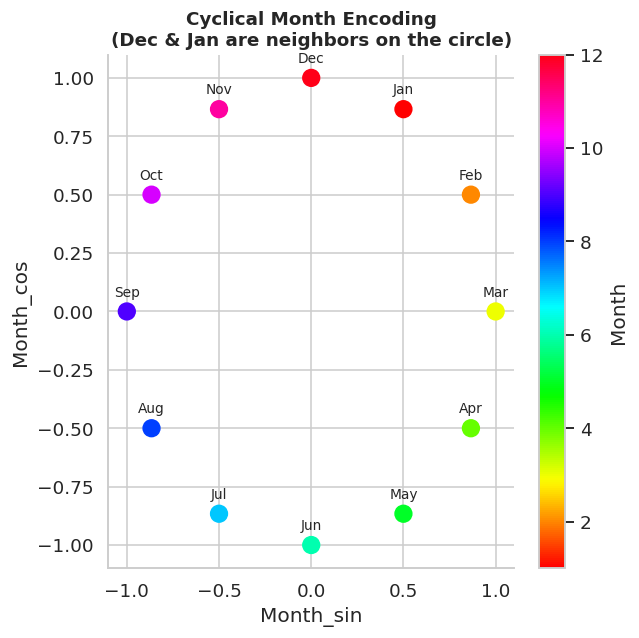

In [86]:

month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

sample = df[["Month","Month_sin","Month_cos"]].drop_duplicates().sort_values("Month")

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(sample["Month_sin"], sample["Month_cos"],
                c=sample["Month"], cmap="hsv", s=120, zorder=5)
for _, row in sample.iterrows():
    ax.annotate(month_map[int(row["Month"])],
                (row["Month_sin"], row["Month_cos"]),
                fontsize=9, ha="center", va="bottom",
                xytext=(0, 8), textcoords="offset points")
plt.colorbar(sc, label="Month")
ax.set_title("Cyclical Month Encoding\n(Dec & Jan are neighbors on the circle)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Month_sin"); ax.set_ylabel("Month_cos")
plt.tight_layout(); plt.show()

In [87]:
print("Final feature set:")
print(df.columns.tolist())
print()
print(df.dtypes.to_string())

Final feature set:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Quarter', 'Month_sin', 'Month_cos', 'CO2_per_delivery']

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
Quarter                   int64
Month_sin               float64
Month_cos               float64
CO2_per_delivery        float64


In [88]:
TARGET = "Estimated_Deliveries"

FEATURES = [
    "Year", "Month", "Quarter",
    "Month_sin", "Month_cos",
    "Region", "Model",
    "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations",
]

numerical_features   = [
    "Year", "Month", "Quarter", "Month_sin", "Month_cos",
    "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations",
]
categorical_features = ["Region", "Model"]

print(f"Target   : {TARGET}")
print(f"Features : {len(FEATURES)} total")
print(f"  Numeric     : {len(numerical_features)}")
print(f"  Categorical : {len(categorical_features)}")

Target   : Estimated_Deliveries
Features : 12 total
  Numeric     : 10
  Categorical : 2


In [89]:

train = df[df["Year"] <= 2022]
valid = df[df["Year"] == 2023]
test  = df[df["Year"] >= 2024]

X_train = train[FEATURES];  y_train = train[TARGET]
X_valid = valid[FEATURES];  y_valid = valid[TARGET]
X_test  = test[FEATURES];   y_test  = test[TARGET]

print("Time-based split:")
print(f"  Train  2015–2022 : {X_train.shape[0]:>5,} rows")
print(f"  Valid  2023      : {X_valid.shape[0]:>5,} rows")
print(f"  Test   2024–2025 : {X_test.shape[0]:>5,} rows")
print()
print("Why time-based?")
print("  Future data must never leak into training.")
print("  Random split would mix years — that's data leakage.")

Time-based split:
  Train  2015–2022 : 1,920 rows
  Valid  2023      :   240 rows
  Test   2024–2025 :   480 rows

Why time-based?
  Future data must never leak into training.
  Random split would mix years — that's data leakage.


In [90]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])


categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,     numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Preprocessor created")
print()
print("Why OneHotEncoder over LabelEncoder?")
print("  LabelEncoder: Asia=0, Europe=1, NA=2 → implies fake ordering")
print("  OneHotEncoder: creates binary columns → no false relationships")
print()
print("Why StandardScaler?")
print("  Month: 1–12  vs  Price: 40,000–120,000")
print("  Scaling lets all features contribute equally to the model.")

Preprocessor created

Why OneHotEncoder over LabelEncoder?
  LabelEncoder: Asia=0, Europe=1, NA=2 → implies fake ordering
  OneHotEncoder: creates binary columns → no false relationships

Why StandardScaler?
  Month: 1–12  vs  Price: 40,000–120,000
  Scaling lets all features contribute equally to the model.


In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    """Return a clean metrics dict."""
    return {
        "Model": name,
        "MAE"  : mean_absolute_error(y_true, y_pred),
        "RMSE" : mean_squared_error(y_true, y_pred) ** 0.5,
        "R2"   : r2_score(y_true, y_pred),
    }


lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",         LinearRegression()),
])
lr_model.fit(X_train, y_train)
lr_preds  = lr_model.predict(X_valid)
lr_result = evaluate("Linear Regression", y_valid, lr_preds)

print("=" * 52)
print("  MODEL 1 · LINEAR REGRESSION  (baseline)")
print("=" * 52)
print(f"  MAE  : {lr_result['MAE']:>10,.2f}")
print(f"  RMSE : {lr_result['RMSE']:>10,.2f}")
print(f"  R²   : {lr_result['R2']:>10.4f}")

  MODEL 1 · LINEAR REGRESSION  (baseline)
  MAE  :     576.13
  RMSE :     804.92
  R²   :     0.9500


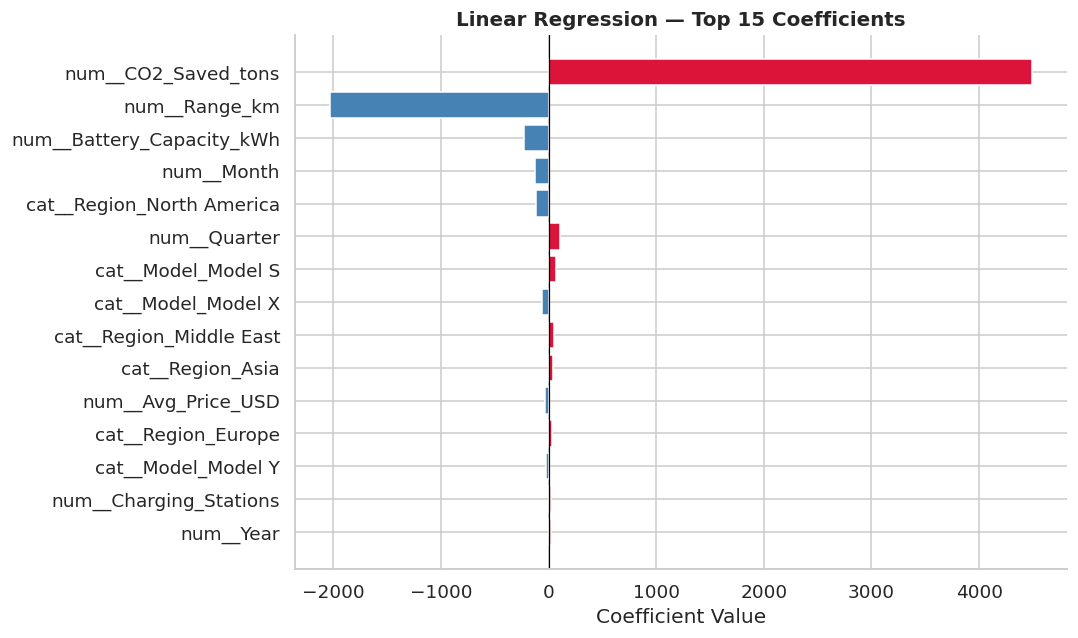

In [92]:

feat_lr  = lr_model.named_steps["preprocessor"].get_feature_names_out()
coef_lr  = lr_model.named_steps["model"].coef_

lr_coef = (
    pd.DataFrame({"Feature": feat_lr, "Coefficient": coef_lr})
    .assign(AbsCoef=lambda d: d["Coefficient"].abs())
    .sort_values("AbsCoef", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
top = lr_coef.head(15)
colors = ["crimson" if c > 0 else "steelblue" for c in top["Coefficient"]]
ax.barh(top["Feature"], top["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression — Top 15 Coefficients", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [93]:
from sklearn.ensemble import RandomForestRegressor


rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",         RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
rf_preds  = rf_model.predict(X_valid)
rf_result = evaluate("Random Forest", y_valid, rf_preds)

print("=" * 52)
print("  MODEL 2 · RANDOM FOREST")
print("=" * 52)
print(f"  MAE  : {rf_result['MAE']:>10,.2f}")
print(f"  RMSE : {rf_result['RMSE']:>10,.2f}")
print(f"  R²   : {rf_result['R2']:>10.4f}")

  MODEL 2 · RANDOM FOREST
  MAE  :     110.71
  RMSE :     183.24
  R²   :     0.9974


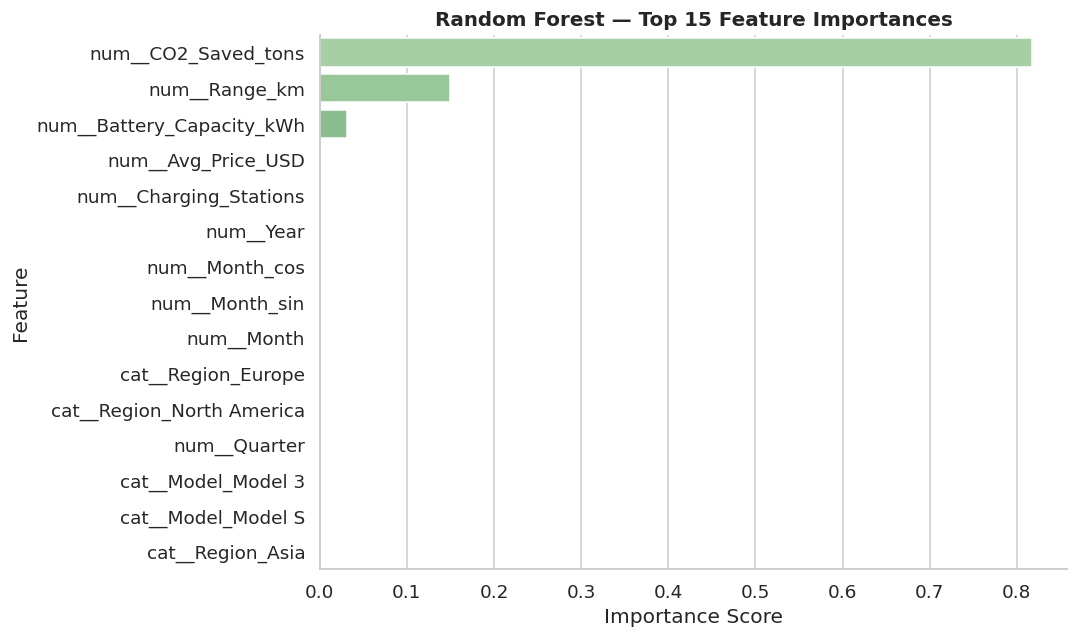

In [94]:

feat_rf = rf_model.named_steps["preprocessor"].get_feature_names_out()
imp_rf  = rf_model.named_steps["model"].feature_importances_

rf_imp = (
    pd.DataFrame({"Feature": feat_rf, "Importance": imp_rf})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_rf = rf_imp.head(15)
sns.barplot(data=top_rf, x="Importance", y="Feature", palette="Greens_d", ax=ax)
ax.set_title("Random Forest — Top 15 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()

In [95]:
from xgboost import XGBRegressor


xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",         XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0,
    )),
])
xgb_model.fit(X_train, y_train)
xgb_preds  = xgb_model.predict(X_valid)
xgb_result = evaluate("XGBoost (Valid)", y_valid, xgb_preds)

print("=" * 52)
print("  MODEL 3 · XGBOOST")
print("=" * 52)
print(f"  MAE  : {xgb_result['MAE']:>10,.2f}")
print(f"  RMSE : {xgb_result['RMSE']:>10,.2f}")
print(f"  R²   : {xgb_result['R2']:>10.4f}")

  MODEL 3 · XGBOOST
  MAE  :     145.87
  RMSE :     218.56
  R²   :     0.9963


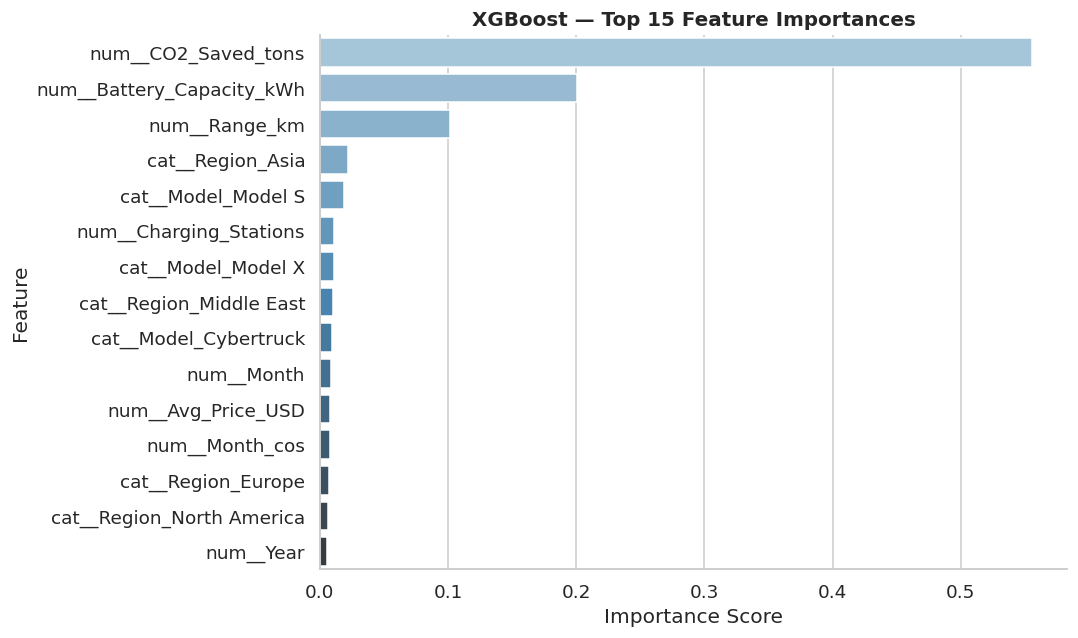

In [96]:

feat_xgb = xgb_model.named_steps["preprocessor"].get_feature_names_out()
imp_xgb  = xgb_model.named_steps["model"].feature_importances_

xgb_imp = (
    pd.DataFrame({"Feature": feat_xgb, "Importance": imp_xgb})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_xgb = xgb_imp.head(15)
sns.barplot(data=top_xgb, x="Importance", y="Feature", palette="Blues_d", ax=ax)
ax.set_title("XGBoost — Top 15 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()

In [97]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score


tscv   = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=tscv, scoring="r2",
)

print("XGBoost — TimeSeriesSplit Cross-Validation (5 folds)")
print("─" * 50)
for i, s in enumerate(scores, 1):
    bar = "█" * int(s * 30)
    print(f"  Fold {i} : R² = {s:.4f}  {bar}")
print("─" * 50)
print(f"  Mean R²  = {scores.mean():.4f}")
print(f"  Std  R²  = {scores.std():.4f}")
print()
print("Why TimeSeriesSplit?")
print("  Standard KFold can mix future with past → data leakage.")
print("  TimeSeriesSplit always trains on past, validates on future.")

XGBoost — TimeSeriesSplit Cross-Validation (5 folds)
──────────────────────────────────────────────────
  Fold 1 : R² = 0.9643  ████████████████████████████
  Fold 2 : R² = 0.9878  █████████████████████████████
  Fold 3 : R² = 0.9789  █████████████████████████████
  Fold 4 : R² = 0.9946  █████████████████████████████
  Fold 5 : R² = 0.9956  █████████████████████████████
──────────────────────────────────────────────────
  Mean R²  = 0.9843
  Std  R²  = 0.0116

Why TimeSeriesSplit?
  Standard KFold can mix future with past → data leakage.
  TimeSeriesSplit always trains on past, validates on future.


  XGBOOST — FINAL TEST SET (2024–2025)
  MAE  :     154.06
  RMSE :     207.59
  R²   :     0.9969


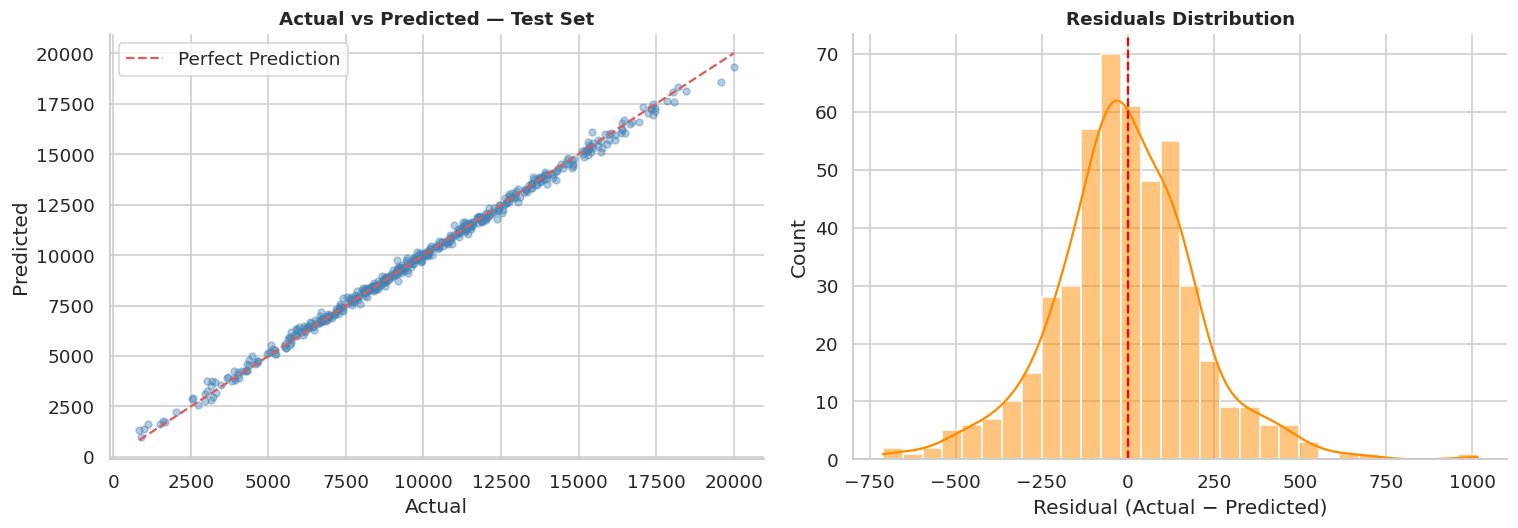

In [98]:

test_preds  = xgb_model.predict(X_test)
test_result = evaluate("XGBoost (Test)", y_test, test_preds)

print("=" * 52)
print("  XGBOOST — FINAL TEST SET (2024–2025)")
print("=" * 52)
print(f"  MAE  : {test_result['MAE']:>10,.2f}")
print(f"  RMSE : {test_result['RMSE']:>10,.2f}")
print(f"  R²   : {test_result['R2']:>10.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, test_preds, alpha=0.4, color="steelblue", s=20)
lim = [min(y_test.min(), test_preds.min()), max(y_test.max(), test_preds.max())]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Perfect Prediction")
axes[0].set_title("Actual vs Predicted — Test Set", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].legend()

residuals = y_test - test_preds
sns.histplot(residuals, kde=True, bins=30, color="darkorange", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Residual (Actual − Predicted)")

plt.tight_layout(); plt.show()

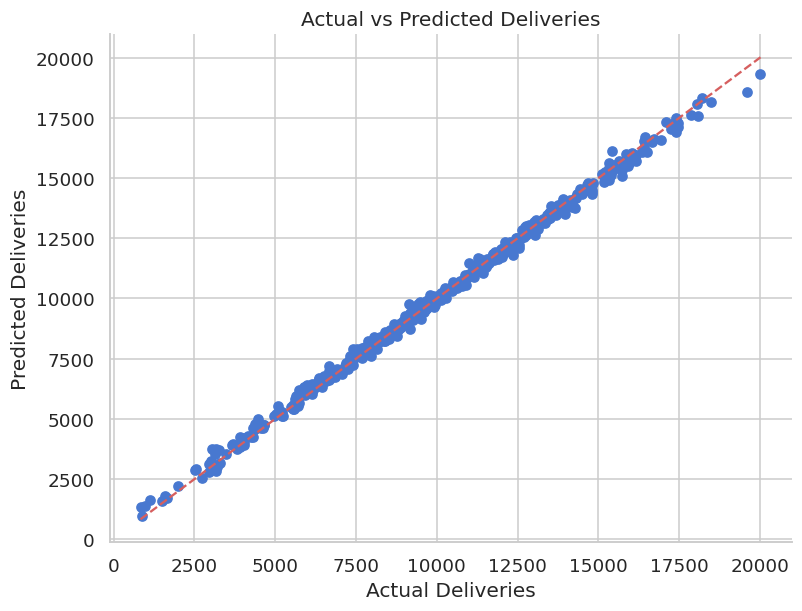

In [99]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_preds
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.show()

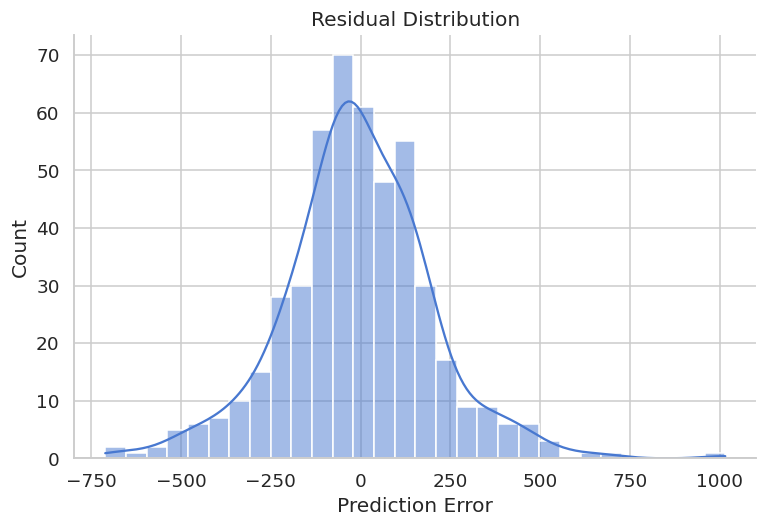

In [100]:
residuals = y_test - test_preds

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

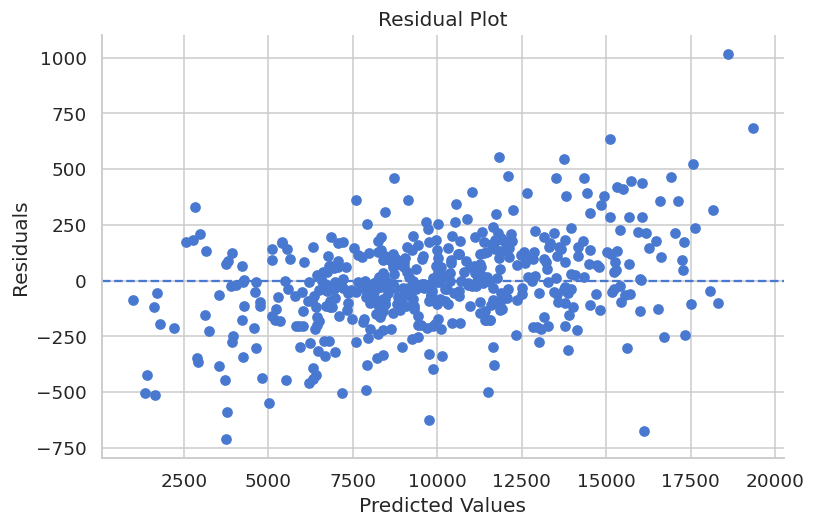

In [101]:
plt.figure(figsize=(8,5))

plt.scatter(
    test_preds,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [102]:
import optuna
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

def objective(trial):

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    return r2_score(y_valid, preds)

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20
)

print("Best Parameters")
print(study.best_params)

print("\nBest Validation R2")
print(study.best_value)

[I 2026-06-07 11:51:33,045] A new study created in memory with name: no-name-d27bf35c-b227-45a3-9eb5-faaa94d03bde
[I 2026-06-07 11:51:33,285] Trial 0 finished with value: 0.9975363612174988 and parameters: {'n_estimators': 360, 'max_depth': 4, 'learning_rate': 0.20690698338312868, 'subsample': 0.9525754160512422, 'colsample_bytree': 0.9604716700011713}. Best is trial 0 with value: 0.9975363612174988.
[I 2026-06-07 11:51:33,481] Trial 1 finished with value: 0.9957129955291748 and parameters: {'n_estimators': 222, 'max_depth': 5, 'learning_rate': 0.15513838779418543, 'subsample': 0.681443200009707, 'colsample_bytree': 0.8201485764997714}. Best is trial 0 with value: 0.9975363612174988.
[I 2026-06-07 11:51:34,223] Trial 2 finished with value: 0.9860503673553467 and parameters: {'n_estimators': 229, 'max_depth': 10, 'learning_rate': 0.08358002802915601, 'subsample': 0.6069163068781048, 'colsample_bytree': 0.8165544358862061}. Best is trial 0 with value: 0.9975363612174988.
[I 2026-06-07 11

Best Parameters
{'n_estimators': 293, 'max_depth': 10, 'learning_rate': 0.09148083672380074, 'subsample': 0.7465617502382319, 'colsample_bytree': 0.9659919902118443}

Best Validation R2
0.9982971549034119


In [103]:
best_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study.best_params,
        random_state=42
    ))
])

best_xgb.fit(X_train, y_train)

best_preds = best_xgb.predict(X_test)

best_result = evaluate(
    "Tuned XGBoost",
    y_test,
    best_preds
)

print("=" * 52)
print("TUNED XGBOOST RESULTS")
print("=" * 52)

print(f"MAE  : {best_result['MAE']:>10,.2f}")
print(f"RMSE : {best_result['RMSE']:>10,.2f}")
print(f"R²   : {best_result['R2']:>10.4f}")

TUNED XGBOOST RESULTS
MAE  :     115.82
RMSE :     162.25
R²   :     0.9981


In [104]:
print("Original XGBoost R2 :", test_result["R2"])
print("Tuned XGBoost R2    :", best_result["R2"])

Original XGBoost R2 : 0.9968971014022827
Tuned XGBoost R2    : 0.9981043338775635


In [105]:
!pip install shap -q

In [106]:
import shap



xgb_final = best_xgb.named_steps["model"]


X_test_transformed = (
    best_xgb.named_steps["preprocessor"]
    .transform(X_test)
)


explainer = shap.TreeExplainer(xgb_final)

shap_values = explainer.shap_values(
    X_test_transformed
)



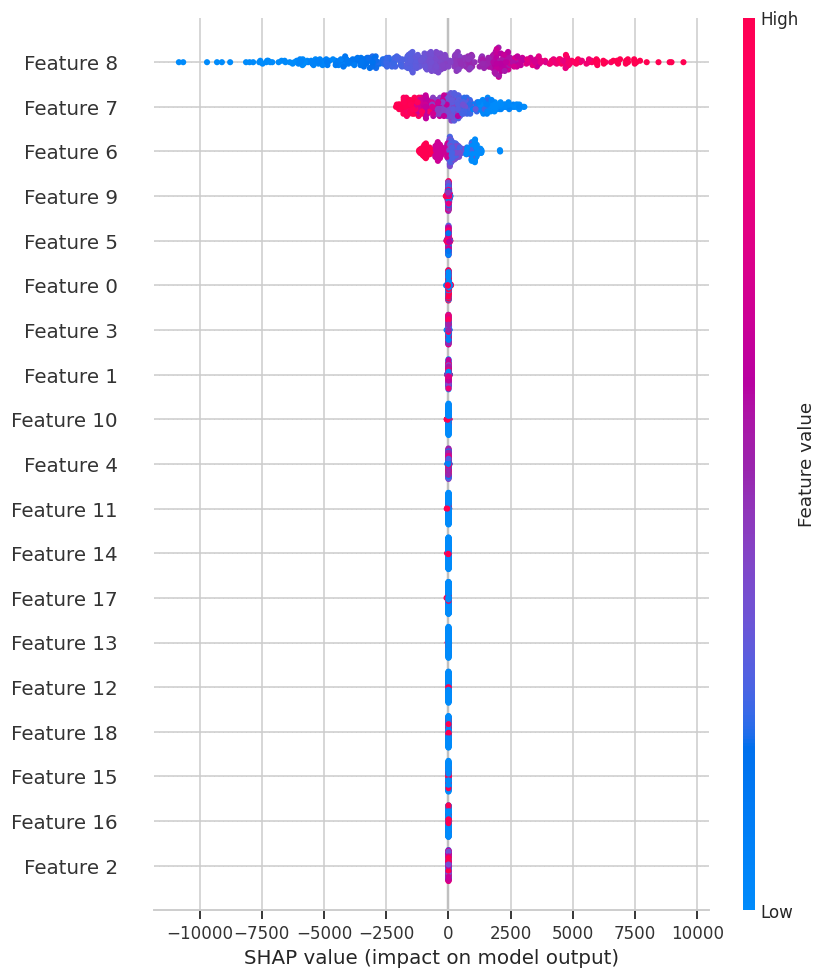

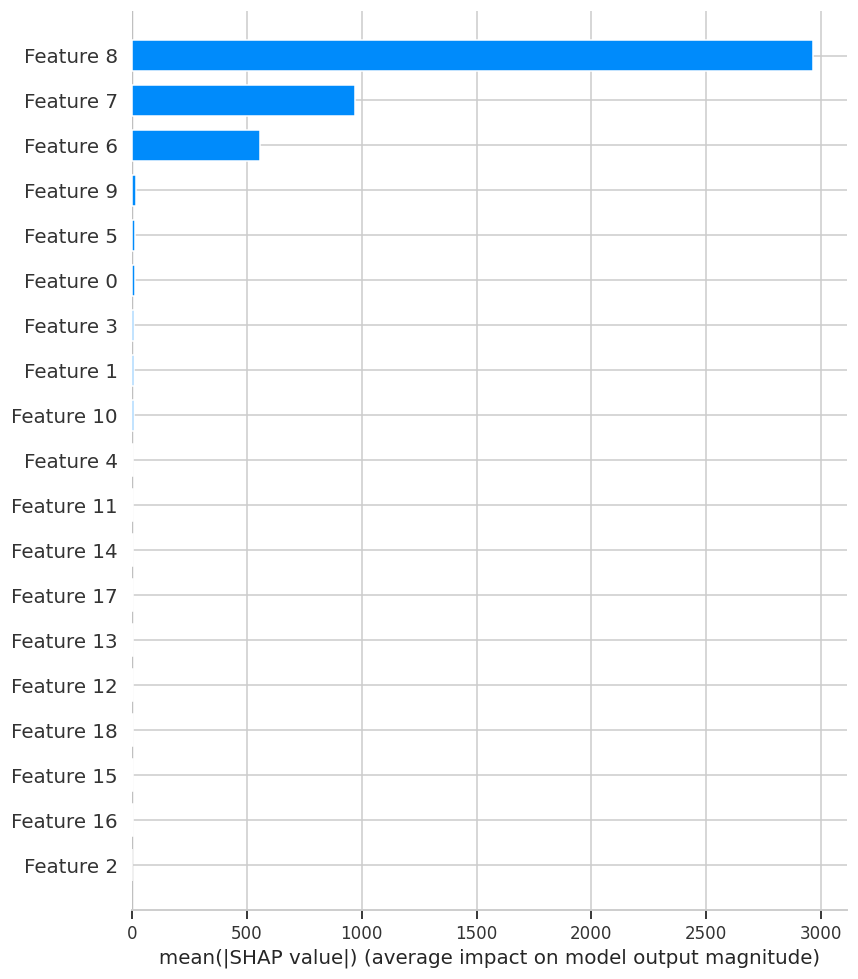

In [107]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    show=True
)
shap.summary_plot(
    shap_values,
    X_test_transformed,
    plot_type="bar",
    show=True
)

In [108]:

df_ts = df.copy()
df_ts["Date"] = pd.to_datetime(
    df_ts["Year"].astype(str) + "-" + df_ts["Month"].astype(str) + "-01"
)

monthly_ts = (
    df_ts.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .sort_index()
    .asfreq("MS")          
)

print(f"Time series: {monthly_ts.shape[0]} monthly observations")
print(f"Date range : {monthly_ts.index[0].date()} → {monthly_ts.index[-1].date()}")
monthly_ts.head(12)

Time series: 132 monthly observations
Date range : 2015-01-01 → 2025-12-01


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
2015-06-01    198787
2015-07-01    177759
2015-08-01    214223
2015-09-01    188448
2015-10-01    221541
2015-11-01    211490
2015-12-01    220332
Freq: MS, Name: Estimated_Deliveries, dtype: int64

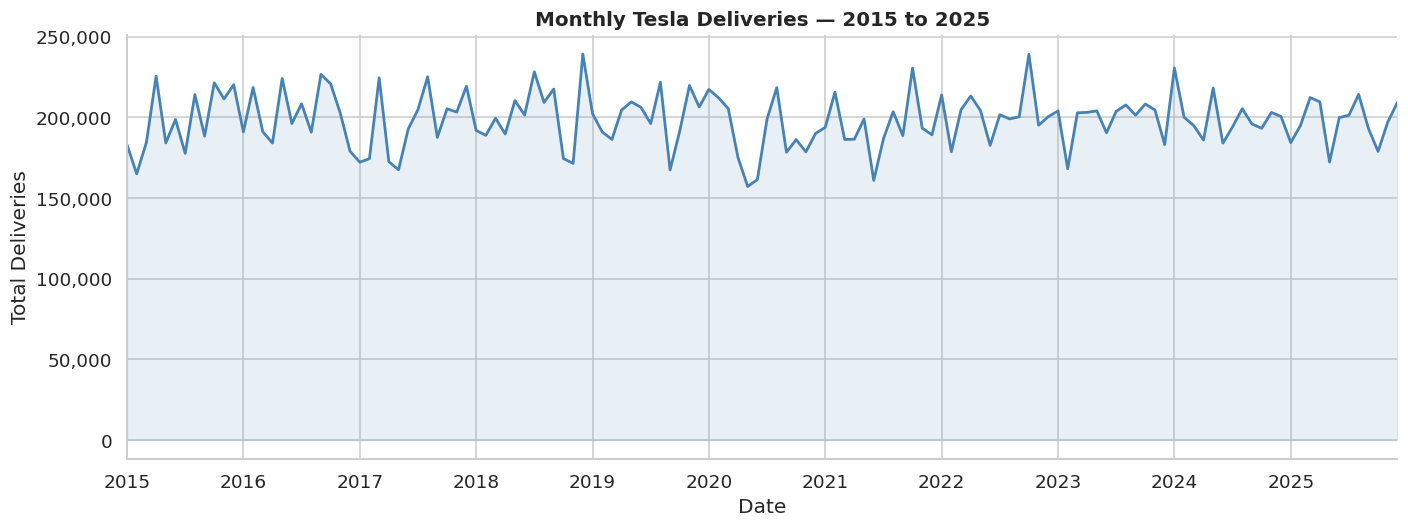

In [109]:

fig, ax = plt.subplots(figsize=(13, 5))
monthly_ts.plot(ax=ax, color="steelblue", linewidth=1.8)
ax.fill_between(monthly_ts.index, monthly_ts, alpha=0.12, color="steelblue")
ax.set_title("Monthly Tesla Deliveries — 2015 to 2025", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout(); plt.show()

AUGMENTED DICKEY-FULLER (ADF) TEST
ADF Statistic : -8.8810
p-value       : 0.000000

Conclusion: The series is stationary.

Generating Seasonal Decomposition Plot...


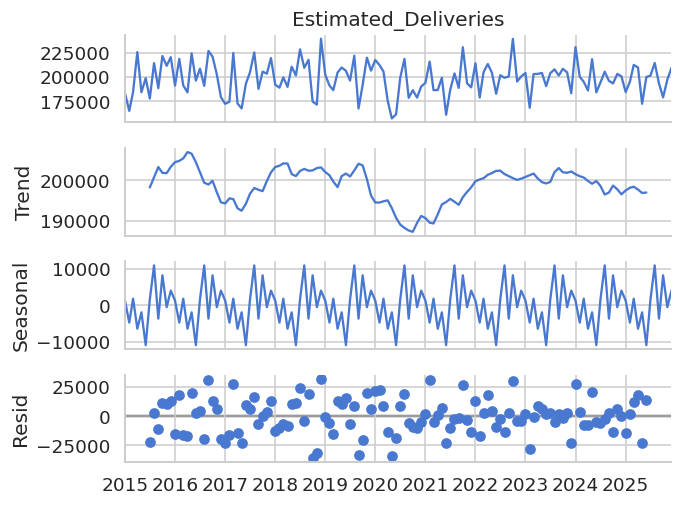

In [110]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

print("=" * 60)
print("AUGMENTED DICKEY-FULLER (ADF) TEST")
print("=" * 60)

adf_result = adfuller(monthly_ts)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.6f}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series is stationary.")
else:
    print("\nConclusion: The series is non-stationary.")

print("\nGenerating Seasonal Decomposition Plot...")

decompose = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

decompose.plot()
plt.show()

In [111]:

train_ts = monthly_ts[:"2022-12-01"]
test_ts  = monthly_ts["2023-01-01":]

print(f"Train (TS) : {train_ts.shape[0]} months  ({train_ts.index[0].date()} → {train_ts.index[-1].date()})")
print(f"Test  (TS) : {test_ts.shape[0]}  months  ({test_ts.index[0].date()} → {test_ts.index[-1].date()})")

Train (TS) : 96 months  (2015-01-01 → 2022-12-01)
Test  (TS) : 36  months  (2023-01-01 → 2025-12-01)


In [112]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_spec = SARIMAX(
    train_ts,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_model = sarima_spec.fit(
    disp=False
)

print(sarima_model.summary())

print("\nAIC :", sarima_model.aic)
print("BIC :", sarima_model.bic)

                                      SARIMAX Results                                       
Dep. Variable:                 Estimated_Deliveries   No. Observations:                   96
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -776.521
Date:                              Sun, 07 Jun 2026   AIC                           1567.042
Time:                                      11:51:56   BIC                           1582.579
Sample:                                  01-01-2015   HQIC                          1573.198
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6124      0.305     -2.008      0.045      -1.210      -0.015
ar.L2          0.00

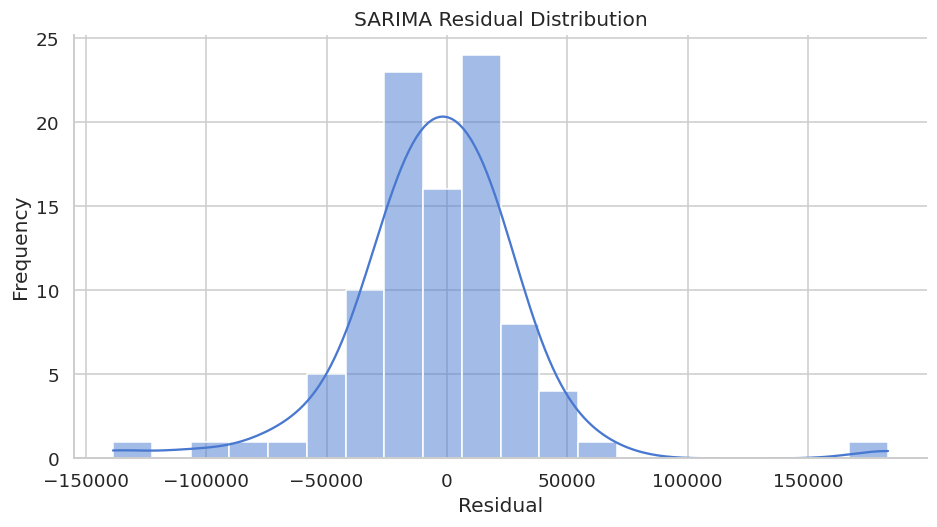

In [113]:
residuals = sarima_model.resid

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [114]:
forecast_sarima       = sarima_model.forecast(steps=len(test_ts))
forecast_sarima.index = test_ts.index          # align index to test dates

sarima_result = evaluate("SARIMA", test_ts, forecast_sarima)

print("=" * 52)
print("  SARIMA — Test Results")
print("=" * 52)
print(f"  MAE  : {sarima_result['MAE']:>10,.2f}")
print(f"  RMSE : {sarima_result['RMSE']:>10,.2f}")
print(f"  R²   : {sarima_result['R2']:>10.4f}")

  SARIMA — Test Results
  MAE  :  17,059.87
  RMSE :  23,699.93
  R²   :    -2.6723


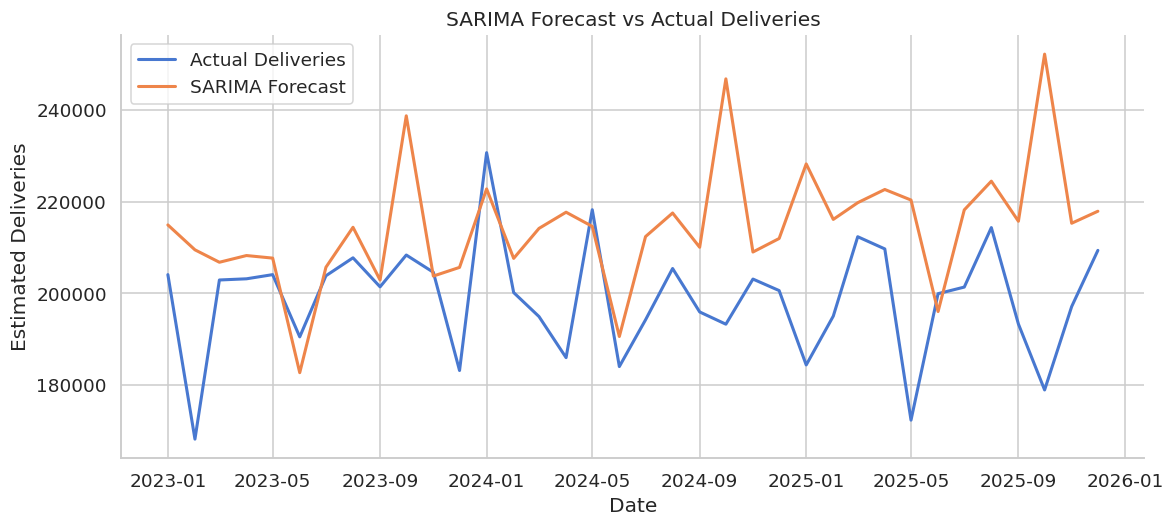

In [115]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ts.index,
    test_ts,
    label="Actual Deliveries",
    linewidth=2
)

plt.plot(
    forecast_sarima.index,
    forecast_sarima,
    label="SARIMA Forecast",
    linewidth=2
)

plt.title("SARIMA Forecast vs Actual Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

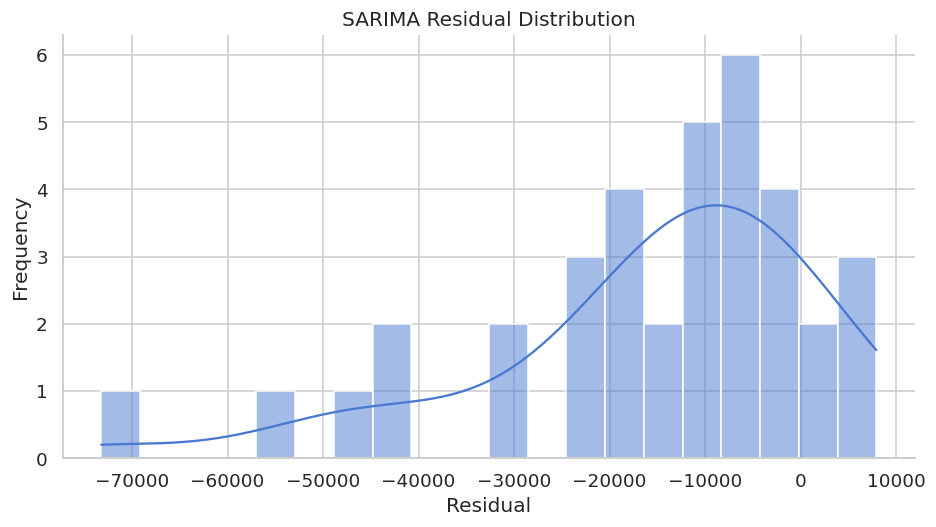

In [116]:
residuals = test_ts - forecast_sarima

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

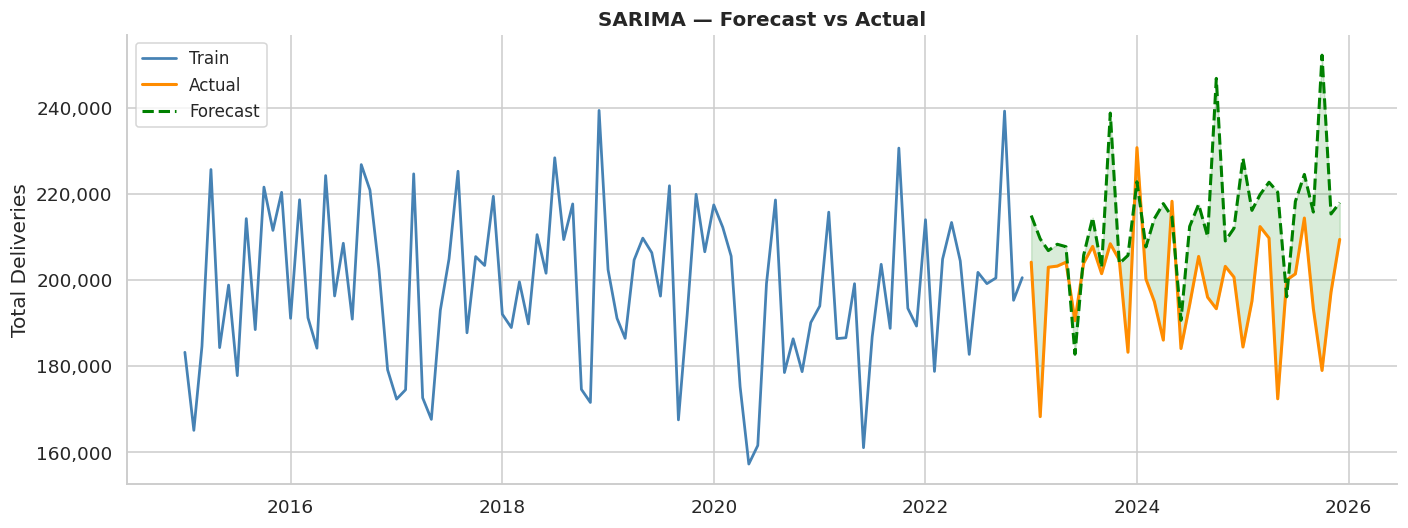

In [117]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_ts.index,        train_ts,        label="Train",    color="steelblue",  lw=1.8)
ax.plot(test_ts.index,         test_ts,         label="Actual",   color="darkorange", lw=2.0)
ax.plot(forecast_sarima.index, forecast_sarima, label="Forecast", color="green",      lw=2.0, ls="--")
ax.fill_between(test_ts.index, test_ts, forecast_sarima, alpha=0.15, color="green")
ax.set_title("SARIMA — Forecast vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

In [118]:

import subprocess
subprocess.run(["pip", "install", "pmdarima", "-q"], check=True)
from pmdarima import auto_arima
print("pmdarima ready")

pmdarima ready


In [119]:

auto_model = auto_arima(
    train_ts,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=None, D=None,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)
print()
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2159.723, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2163.393, Time=0.36 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2163.512, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2617.169, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=2161.723, Time=0.06 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=2161.722, Time=0.06 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=2163.722, Time=0.15 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2161.394, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2161.513, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=2163.381, Time=0.06 sec

Best model:  ARIMA(0,0,0)(0,0,0)[12] intercept
Total fit time: 0.870 seconds

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                        SARIMAX   Log Likeli

In [120]:
forecast_auto = pd.Series(
    auto_model.predict(n_periods=len(test_ts)),
    index=test_ts.index,
)

auto_result = evaluate("Auto ARIMA", test_ts, forecast_auto)

print("=" * 52)
print("  AUTO ARIMA — Test Results")
print("=" * 52)
print(f"  MAE  : {auto_result['MAE']:>10,.2f}")
print(f"  RMSE : {auto_result['RMSE']:>10,.2f}")
print(f"  R²   : {auto_result['R2']:>10.4f}")

  AUTO ARIMA — Test Results
  MAE  :   9,563.93
  RMSE :  12,378.53
  R²   :    -0.0018


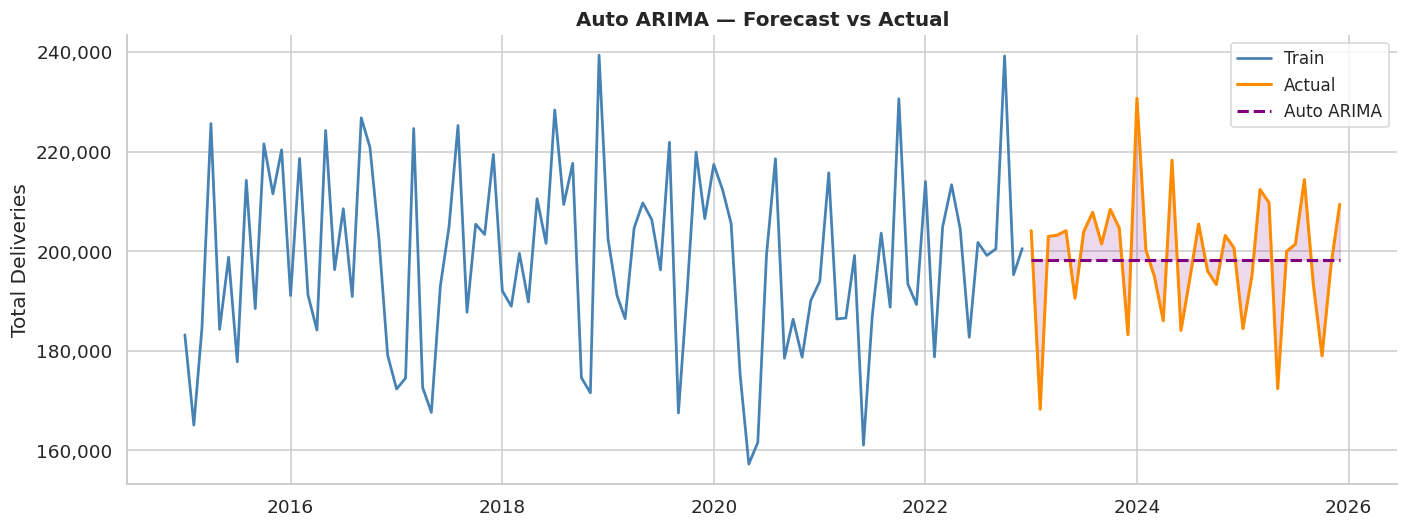

In [121]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_ts.index,       train_ts,      label="Train",      color="steelblue",  lw=1.8)
ax.plot(test_ts.index,        test_ts,       label="Actual",     color="darkorange", lw=2.0)
ax.plot(forecast_auto.index,  forecast_auto, label="Auto ARIMA", color="purple",     lw=2.0, ls="--")
ax.fill_between(test_ts.index, test_ts, forecast_auto, alpha=0.15, color="purple")
ax.set_title("Auto ARIMA — Forecast vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

In [122]:


lr_test_preds = lr_model.predict(X_test)

rf_test_preds = rf_model.predict(X_test)

In [123]:
comparison = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_test_preds),
    evaluate("Random Forest",     y_test, rf_test_preds),
    evaluate("XGBoost",           y_test, test_preds),
    evaluate("SARIMA",            test_ts, forecast_sarima),
    evaluate("Auto ARIMA",        test_ts, forecast_auto),
]).sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

comparison.index = comparison.index + 1
comparison.insert(
    0,
    "Rank",
    comparison.index
)

print("Final Model Comparison:")
print(comparison.to_string(index=False))

Final Model Comparison:
 Rank             Model          MAE         RMSE        R2
    1     Random Forest   111.502358   180.141060  0.997663
    2           XGBoost   154.059906   207.586324  0.996897
    3 Linear Regression   615.664547   856.906786  0.947127
    4        Auto ARIMA  9563.932292 12378.527798 -0.001804
    5            SARIMA 17059.866592 23699.925545 -2.672304


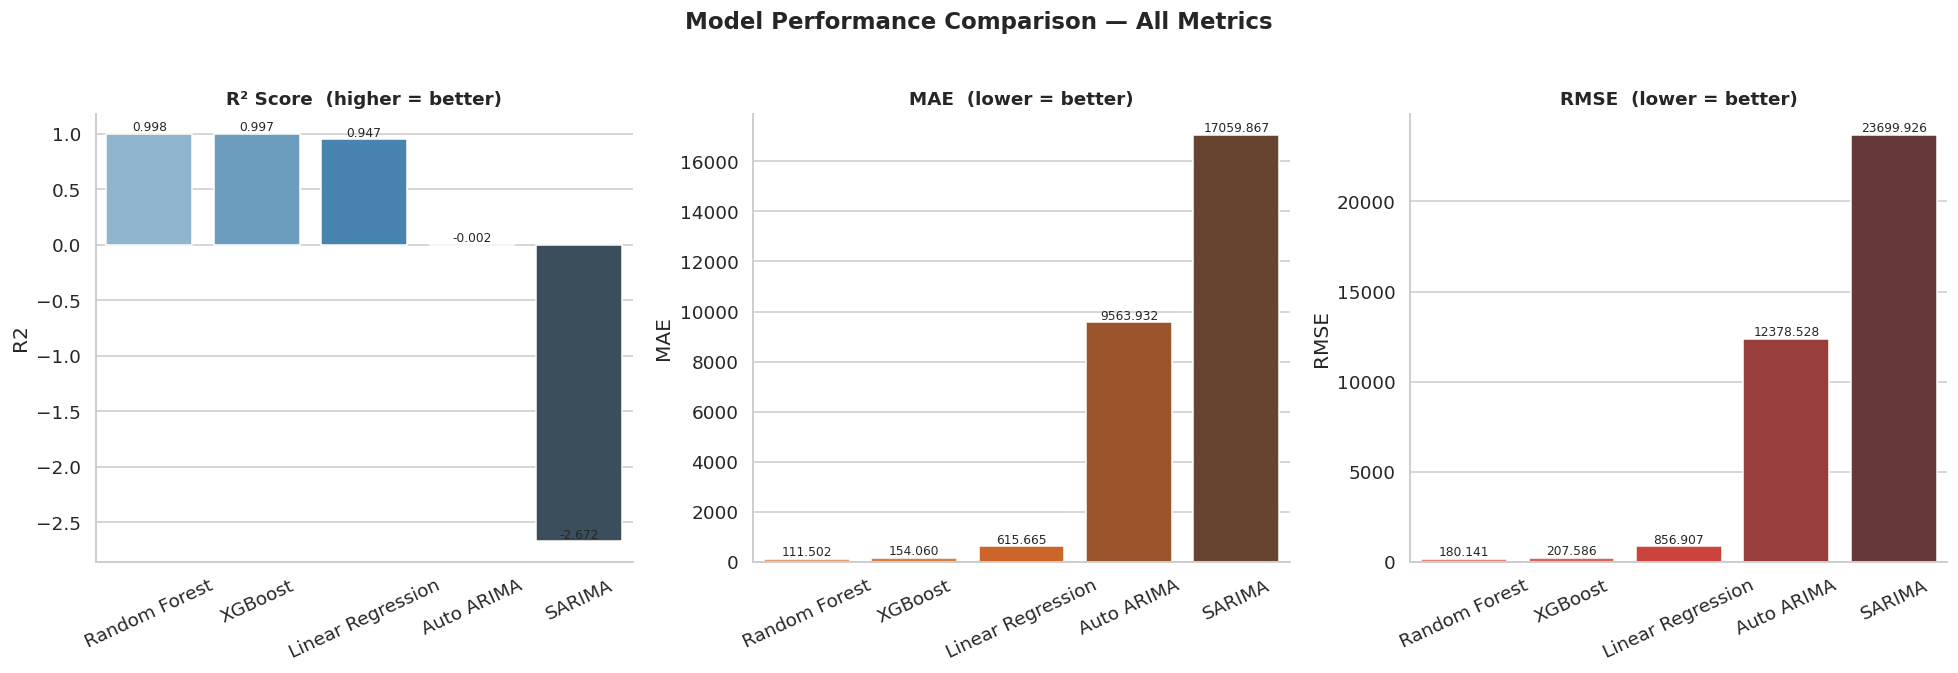

In [124]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
order = comparison["Model"].tolist()

for ax, metric, pal, title in zip(
    axes,
    ["R2", "MAE", "RMSE"],
    ["Blues_d", "Oranges_d", "Reds_d"],
    ["R² Score  (higher = better)",
     "MAE  (lower = better)",
     "RMSE  (lower = better)"],
):
    bars = sns.barplot(data=comparison, x="Model", y=metric,
                       order=order, palette=pal, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    for p in bars.patches:
        h = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, h,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Model Performance Comparison — All Metrics",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

In [125]:
best_model = comparison.sort_values(
    by="R2",
    ascending=False
).iloc[0]

print("FINAL WINNER")

print(f"Model : {best_model['Model']}")
print(f"R²    : {best_model['R2']:.4f}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"RMSE  : {best_model['RMSE']:.2f}")

FINAL WINNER
Model : Random Forest
R²    : 0.9977
MAE   : 111.50
RMSE  : 180.14


In [126]:
print("""

TESLA VEHICLE DELIVERY PREDICTION PROJECT REPORT

PROJECT OVERVIEW

The objective of this project was to predict Tesla vehicle deliveries
using historical Tesla EV data from 2015 to 2025.

I selected Estimated_Deliveries as the target variable because
vehicle delivery forecasting is an important business problem.
Accurate delivery predictions help companies estimate demand,
production requirements, inventory planning, and future growth.

────────────────────────────────────────────────────────────

DATA UNDERSTANDING

The dataset contains information related to Tesla vehicles,
pricing, battery specifications, charging infrastructure,
regional information, environmental impact, and deliveries.

The target variable selected for prediction was:

Estimated_Deliveries

The dataset contained both numerical and categorical features,
making it suitable for machine learning as well as time-series analysis.

────────────────────────────────────────────────────────────

DATA QUALITY ANALYSIS

Before building any model, I performed a complete data quality check.

The following checks were performed:

• Missing Values
• Duplicate Records
• Data Types
• Statistical Summary

Results:

• No missing values were found.
• No duplicate records were found.
• Data types were already appropriate.

Since the dataset was clean, no major data cleaning was required.

────────────────────────────────────────────────────────────

EXPLORATORY DATA ANALYSIS (EDA)

To understand the dataset better, I performed exploratory data analysis.

The following visualizations were created:

• Histograms
• Boxplots
• Correlation Heatmap
• Monthly Delivery Trends
• Regional Analysis
• Model-wise Analysis
• Year-wise Trends
• Feature Relationship Analysis

EDA helped me understand the distribution of deliveries,
identify patterns, and detect potential issues before modeling.

────────────────────────────────────────────────────────────

DATA LEAKAGE DETECTION

One of the most important steps in this project was checking
for data leakage.

Using the correlation heatmap, I found that:

Production_Units

had an extremely high correlation with Estimated_Deliveries.

This means the model could almost directly infer the target
from this feature.

Including this feature would artificially inflate performance
and make the model unrealistic.

Therefore, I removed Production_Units from the dataset.

This decision improved the reliability and fairness of the model.

────────────────────────────────────────────────────────────

FEATURE ENGINEERING

To improve predictive performance, I created additional features.

Created Features:

• Quarter
• Month_sin
• Month_cos
• CO2_per_Delivery

Reasoning:

Quarter:
Captures quarterly business patterns.

Month_sin and Month_cos:
Months are cyclical in nature.
December and January are close in reality,
but numerically they appear far apart.

Using sine and cosine transformations helps models
learn seasonal patterns more effectively.

CO2_per_Delivery:
Provides environmental efficiency information
relative to delivery volume.

────────────────────────────────────────────────────────────

ENCODING AND SCALING

Categorical Features:

• Region
• Model

Encoding Method:

OneHotEncoder

Reason:

The categories do not have any natural ordering.
OneHotEncoder prevents the model from assuming
incorrect relationships between categories.

Scaling Method:

StandardScaler

Reason:

Different features exist on different scales.

Examples:

Month → 1 to 12
Price → tens of thousands

Scaling ensures balanced contribution during training.

────────────────────────────────────────────────────────────

TIME-BASED DATA SPLITTING

Since this is forecasting data,
I avoided random train-test splitting.

The data was divided chronologically:

Training Data:
2015 – 2022

Validation Data:
2023

Testing Data:
2024 – 2025

This approach simulates real-world forecasting,
where future information should never be used
to predict past outcomes.

────────────────────────────────────────────────────────────

PIPELINE DESIGN

I used machine learning pipelines to automate
the preprocessing and training workflow.

Pipeline Components:

1. Numerical preprocessing
2. Categorical preprocessing
3. Encoding
4. Scaling
5. Model training

Benefits of Pipelines:

• Prevent data leakage
• Ensure consistent preprocessing
• Simplify model training
• Improve reproducibility

Using pipelines makes the solution more production-ready.

────────────────────────────────────────────────────────────

MODEL DEVELOPMENT

The following models were trained and evaluated:

1. Linear Regression
2. Random Forest
3. XGBoost
4. SARIMA
5. Auto ARIMA

Reason for choosing these models:

Linear Regression:
Used as a baseline model.

Random Forest:
Captures complex non-linear relationships.

XGBoost:
A powerful gradient boosting algorithm
known for strong performance on tabular data.

SARIMA:
Traditional statistical forecasting model
that uses trend and seasonality.

Auto ARIMA:
Automatically searches for optimal ARIMA parameters.

────────────────────────────────────────────────────────────

CROSS VALIDATION

TimeSeriesSplit was used instead of standard K-Fold.

Reason:

Traditional K-Fold may allow future observations
to leak into training folds.

TimeSeriesSplit preserves chronological order
and provides more realistic validation.

────────────────────────────────────────────────────────────

HYPERPARAMETER TUNING

To improve XGBoost performance,
Optuna was used for automated hyperparameter tuning.

Benefits:

• Efficient parameter search
• Improved model performance
• Reduced manual experimentation

This helped identify better parameter combinations
than default settings.

────────────────────────────────────────────────────────────

MODEL INTERPRETABILITY

To understand model decisions,
I used:

• Feature Importance Analysis
• SHAP (SHapley Additive Explanations)

SHAP explains how individual features
influence model predictions.

This makes the model more transparent
and easier to interpret.

────────────────────────────────────────────────────────────

TIME SERIES ANALYSIS

For forecasting analysis:

• Monthly aggregation was performed.
• ADF Test was conducted.
• Seasonal decomposition was analyzed.
• SARIMA forecasting was implemented.
• Auto ARIMA forecasting was implemented.

ADF Test:

The Augmented Dickey-Fuller test was used
to evaluate stationarity before forecasting.

Forecast plots and residual analysis were also created
to evaluate forecasting performance.

────────────────────────────────────────────────────────────

FINAL MODEL COMPARISON

All models were evaluated using:

• MAE
• RMSE
• R² Score

Final Ranking:

1. Random Forest
2. XGBoost
3. Linear Regression
4. Auto ARIMA
5. SARIMA

Random Forest achieved the highest R² score
and the lowest prediction errors on the unseen
test dataset.

────────────────────────────────────────────────────────────

FINAL MODEL SELECTION

Random Forest was selected as the final model because:

• Highest R² Score
• Lowest MAE
• Lowest RMSE
• Strong generalization on unseen data
• Stable performance across evaluation stages

Although XGBoost performed extremely well,
Random Forest achieved slightly better
test performance.

────────────────────────────────────────────────────────────

KEY LEARNINGS

Through this project I learned:

• Data Understanding
• Data Quality Analysis
• Exploratory Data Analysis
• Data Leakage Detection
• Feature Engineering
• Encoding Techniques
• Feature Scaling
• Pipeline Design
• Machine Learning Modeling
• Time Series Forecasting
• Cross Validation
• Hyperparameter Tuning
• Model Interpretability using SHAP
• Model Comparison
• Business-Oriented Decision Making

The most important lesson was that
high accuracy alone is not enough.

A good machine learning solution must also be:

• Fair
• Explainable
• Reliable
• Realistic
• Free from data leakage

────────────────────────────────────────────────────────────

CONCLUSION

In this project, I developed a complete machine learning
and forecasting pipeline for Tesla vehicle delivery prediction.

The workflow included:

• Data Analysis
• Data Cleaning Verification
• Leakage Detection
• Feature Engineering
• Preprocessing Pipelines
• Machine Learning Models
• Time Series Models
• Hyperparameter Tuning
• Explainability Analysis
• Model Comparison

After evaluating multiple approaches,
Random Forest was selected as the final model.

The final solution achieved excellent predictive performance
and demonstrates a complete end-to-end machine learning workflow.

""")



TESLA VEHICLE DELIVERY PREDICTION PROJECT REPORT

PROJECT OVERVIEW

The objective of this project was to predict Tesla vehicle deliveries
using historical Tesla EV data from 2015 to 2025.

I selected Estimated_Deliveries as the target variable because
vehicle delivery forecasting is an important business problem.
Accurate delivery predictions help companies estimate demand,
production requirements, inventory planning, and future growth.

────────────────────────────────────────────────────────────

DATA UNDERSTANDING

The dataset contains information related to Tesla vehicles,
pricing, battery specifications, charging infrastructure,
regional information, environmental impact, and deliveries.

The target variable selected for prediction was:

Estimated_Deliveries

The dataset contained both numerical and categorical features,
making it suitable for machine learning as well as time-series analysis.

────────────────────────────────────────────────────────────

DATA QUALITY ANALYSIS

B